In [1]:
import tensorflow as tf
from tensorflow import keras

2026-02-08 12:51:52.584302: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-08 12:51:52.647436: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX_VNNI, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
from keras import models
from keras import layers
from keras import initializers
from keras import activations
model = models.Sequential()
model.add(layers.Flatten(input_shape=[32, 32, 3]))
for i in range(0, 20):
    model.add(layers.Dense(100, 
                           activation="elu", 
                           kernel_initializer="he_normal"))
model.add(layers.Dense(10, activation="softmax"))

/home/josh/miniforge3/envs/ml-env/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()

/home/josh/miniforge3/envs/ml-env/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [4]:
X_train_full = X_train_full / 255.

In [5]:
X_test = X_test / 255.

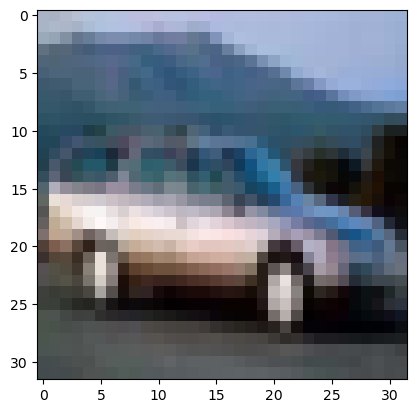

In [6]:
import matplotlib.pyplot as plt
plt.imshow(X_train_full[4])

In [ ]:
from keras import callbacks
from keras import optimizers

K = keras.backend

class ExponentialLearningRate(callbacks.Callback):
    def __init__(self, factor):
        self.factor = factor
        self.rates = []
        self.losses = []
    def on_batch_end(self, batch, logs=None):
        lr = K.eval(self.model.optimizer.learning_rate)
        self.rates.append(K.eval(self.model.optimizer.learning_rate))
        self.losses.append(logs["loss"])
        self.model.optimizer.learning_rate.assign(lr * self.factor)

In [8]:

optimizer = optimizers.Nadam(learning_rate=1e-6)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
expon_lr = ExponentialLearningRate(factor=1.005)

In [ ]:
history = model.fit(X_train_full, y_train_full, epochs=1,
                    validation_split=0.1, callbacks=[expon_lr])

Epoch 1/2


KeyboardInterrupt: 

In [ ]:
plt.plot(expon_lr.rates, expon_lr.losses)
plt.gca().set_xscale('log')
plt.hlines(min(expon_lr.losses), min(expon_lr.rates), max(expon_lr.rates))
plt.axis([min(expon_lr.rates), max(expon_lr.rates), 0, expon_lr.losses[0]])
plt.grid()
plt.xlabel("Learning rate")
plt.ylabel("Loss")

TypeError: '>' not supported between instances of 'float' and 'list'

Text(0, 0.5, 'Loss')

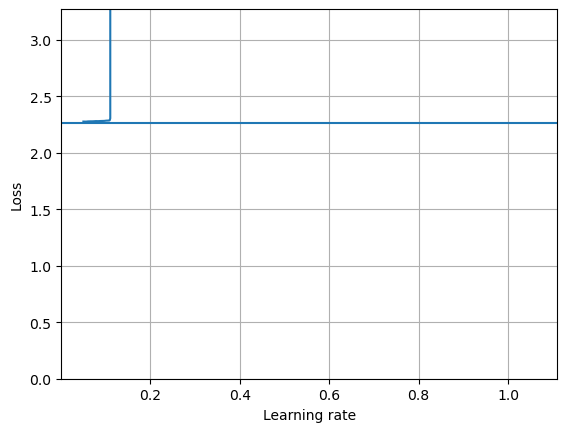

In [19]:
import numpy as np
rates = np.array(expon_lr.rates)
losses = np.array(expon_lr.losses)
mask = (rates > 0.05) & (rates < 0.2)

plt.plot(rates[mask], losses[mask])
plt.hlines(min(losses), min(rates), max(rates))
plt.axis([min(expon_lr.rates), max(expon_lr.rates), 0, expon_lr.losses[0]])
plt.grid()
plt.xlabel("Learning rate")
plt.ylabel("Loss")

In [17]:
keras.backend.clear_session()


In [8]:
from keras import optimizers
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizers.SGD(learning_rate=0.05),
              metrics=["accuracy"])

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full)

In [10]:
import os
run_index = 1
run_logdir = os.path.join(os.curdir, "my_cifar_logs", "run_{:03d}".format(run_index))

In [11]:
run_logdir

'./my_cifar_logs/run_001'

In [12]:
from keras import callbacks

In [31]:
X_val

array([[[[0.34509804, 0.28627451, 0.18039216],
         [0.40392157, 0.33333333, 0.23137255],
         [0.38431373, 0.32156863, 0.23137255],
         ...,
         [0.74117647, 0.67058824, 0.68627451],
         [0.79215686, 0.74901961, 0.76862745],
         [0.78823529, 0.76862745, 0.79607843]],

        [[0.35294118, 0.28627451, 0.18039216],
         [0.40392157, 0.3254902 , 0.21960784],
         [0.40392157, 0.33333333, 0.24313725],
         ...,
         [0.78039216, 0.72156863, 0.73333333],
         [0.80392157, 0.76470588, 0.78431373],
         [0.78823529, 0.77254902, 0.79607843]],

        [[0.35686275, 0.29019608, 0.18039216],
         [0.40392157, 0.3254902 , 0.21568627],
         [0.42352941, 0.34901961, 0.25098039],
         ...,
         [0.80392157, 0.75686275, 0.76470588],
         [0.81568627, 0.78039216, 0.79607843],
         [0.81568627, 0.79607843, 0.81960784]],

        ...,

        [[0.90588235, 0.94509804, 0.95294118],
         [0.88235294, 0.90196078, 0.90588235]

In [32]:
y_val

array([[3],
       [0],
       [0],
       ...,
       [0],
       [6],
       [2]], shape=(12500, 1), dtype=uint8)

In [33]:
early_stopping_cb = callbacks.EarlyStopping(patience=20)
checkpoint_cb = callbacks.ModelCheckpoint("my_cifar_model.h5", save_best_only=True)
tensorboard_cb = callbacks.TensorBoard(run_logdir)

history = model.fit(X_train, y_train, epochs=100, 
                    validation_data=(X_val, y_val), callbacks=[checkpoint_cb, early_stopping_cb, tensorboard_cb])

Epoch 1/100
1171/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0993 - loss: nan

1172/1172 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.0994 - loss: nan - val_accuracy: 0.1019 - val_loss: nan
Epoch 2/100
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.0994 - loss: nan - val_accuracy: 0.1019 - val_loss: nan
Epoch 3/100
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.0994 - loss: nan - val_accuracy: 0.1019 - val_loss: nan
Epoch 4/100
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.0994 - loss: nan - val_accuracy: 0.1019 - val_loss: nan
Epoch 5/100
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.0994 - loss: nan - val_accuracy: 0.1019 - val_loss: nan
Epoch 6/100
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.0994 - loss: nan - val_accuracy: 0.1019 - val_loss: nan
Epoch 7/100
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.0994 - loss: nan - val_accuracy: 0.1019 - val_loss: nan
Epoch 8/100
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.0994 - loss: nan - val_accuracy: 0.1019 - val_loss: nan
Epoch 9/100

In [34]:
model = models.Sequential()
model.add(layers.Flatten(input_shape=[32, 32, 3]))
model.add(layers.BatchNormalization())
for i in range(0, 20):
    model.add(layers.Dense(100, 
                           activation="elu", 
                           kernel_initializer="he_normal"))
    model.add(layers.BatchNormalization())
model.add(layers.Dense(10, activation="softmax"))


/home/josh/miniforge3/envs/ml-env/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [35]:
from keras import optimizers
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizers.Nadam(learning_rate=0.05),
              metrics=["accuracy"])

In [ ]:
model.fit()